# Laboratorio 4 - Modelación basada en agentes

**Curso:** CC2017 - Modelación y Simulación  
**Entrega parcial:** Tasks 1 y 2  
**Integrantes:** *completar antes de entregar*

Este notebook construye en Mesa un modelo reproducible de movilidad urbana, verifica su infraestructura y compara los escenarios con y sin una política de bicicletas compartidas. Se fijan semillas en todas las etapas estocásticas.


## Alcance, escala y supuestos explícitos

- La ciudad es una cuadrícula `MultiGrid` de 20 por 20 celdas; una celda representa aproximadamente un kilómetro y un paso representa una unidad de avance del viaje.
- Se usa `RandomActivation`: los viajeros toman decisiones y ocupan espacio sin un reloj global que haga simultáneas todas las acciones. El orden aleatorio evita favorecer sistemáticamente a los identificadores bajos cuando dos personas compiten por una celda. Esta elección modela la asincronía del proceso real, no una conveniencia de programación.
- Cada automóvil se representa con un `VehicleAgent` pasivo que se desplaza junto a su `CommutterAgent`. Al terminar el viaje se elimina a la persona del *schedule* y de la cuadrícula, como exige la consigna, mientras el vehículo queda registrado en la celda destino para construir el mapa final. Si también se eliminaran todos los vehículos al terminar todos los viajes, el indicador final sería siempre cero.
- El horizonte final se fija en $T=40$ pasos para que todas las réplicas sean comparables. Una ruta Manhattan sin bloqueo mide como máximo 38 celdas; los bloqueos por ocupación pueden dejar algunos viajes pendientes al alcanzar el horizonte.
- Una distancia muestreada se conserva sin truncar para no alterar la normal multivariada. Solo al convertir kilómetros a una ruta discreta se redondea y limita la longitud a lo que admite la cuadrícula.
- El índice solicitado es una densidad espacial media: al sumar el mapa y dividir entre 400, depende del número de vehículos presentes, no de qué tan concentrados estén. Esta limitación se retoma en la interpretación.


In [1]:
import math
import warnings
from functools import lru_cache

import matplotlib.pyplot as plt
import mesa
import numpy as np
from mesa import Agent, Model
from mesa.space import MultiGrid
from mesa.time import RandomActivation

warnings.filterwarnings(
    "ignore",
    message="The time module and all its Schedulers are deprecated",
    category=FutureWarning,
)

N_COMMUTERS = 150
WIDTH = HEIGHT = 20
N_CELLS = WIDTH * HEIGHT

# Parámetros especificados en la hoja de trabajo.
MU = np.array([8_500.0, 6.5])
SIGMA = np.array([[4_000_000.0, -800.0], [-800.0, 4.0]])

print(f"Mesa: {mesa.__version__}")
print(f"NumPy: {np.__version__}")


Mesa: 2.4.0
NumPy: 2.5.2


## Task 1.1 - Inicialización, elección modal y scheduling

### 1.1(a) Normal multivariada mediante Cholesky

Si la matriz de covarianza satisface $\Sigma=LL^{\mathsf T}$ y $Z$ contiene normales estándar independientes, entonces

$$X=\mu+ZL^{\mathsf T}$$

tiene media $\mu$ y covarianza $\Sigma$. La correlación poblacional especificada es $-800/(2000\cdot2)=-0.20$.


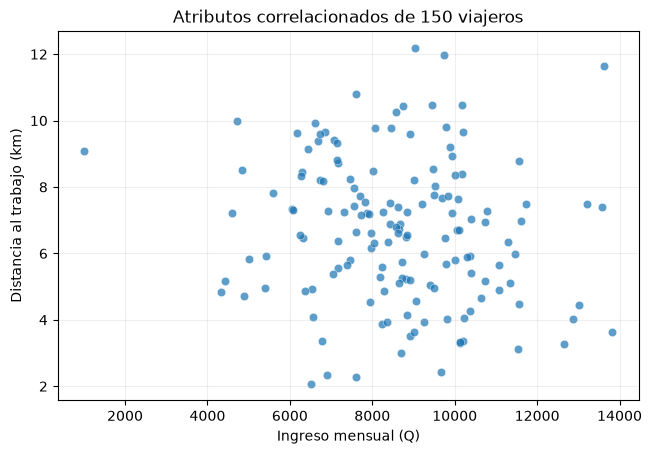

Correlación poblacional especificada: -0.200
Correlación muestral: -0.130
Verificación de signo: PASA


In [3]:
def generate_commuter_attributes(n, rng):
    '''Genera [ingreso, distancia] aplicando explícitamente Cholesky.'''
    L = np.linalg.cholesky(SIGMA)
    z = rng.standard_normal((n, 2))
    return MU + z @ L.T


L = np.linalg.cholesky(SIGMA)
assert np.allclose(L @ L.T, SIGMA)

sample_attributes = generate_commuter_attributes(
    N_COMMUTERS, np.random.default_rng(2026)
)
sample_income = sample_attributes[:, 0]
sample_distance = sample_attributes[:, 1]
sample_correlation = np.corrcoef(sample_income, sample_distance)[0, 1]

fig, ax = plt.subplots(figsize=(7.5, 4.8))
ax.scatter(sample_income, sample_distance, alpha=0.72, edgecolor="white", linewidth=0.35)
ax.set(
    title="Atributos correlacionados de 150 viajeros",
    xlabel="Ingreso mensual (Q)",
    ylabel="Distancia al trabajo (km)",
)
ax.grid(alpha=0.2)
plt.show()

print(f"Correlación poblacional especificada: {-0.20:.3f}")
print(f"Correlación muestral: {sample_correlation:.3f}")
print("Verificación de signo:", "PASA" if sample_correlation < 0 else "FALLA")


### 1.1(b) Regla de elección modal

La regla es **determinista** porque, conocidos `distance` y `policy_active`, siempre devuelve el mismo modo; no contiene una variable aleatoria. Para introducir heterogeneidad se podría calcular una probabilidad logística

$$p_i=\frac{1}{1+\exp[-(\beta_0+\beta_1d_i+\beta_2\,ingreso_i+\beta_3\,congestion_i)]}$$

y elegir bicicleta cuando una realización uniforme sea menor que $p_i$. Así, personas con los mismos atributos observados todavía podrían decidir distinto por preferencias no observadas.

### 1.1(c) Scheduling

Se elige activación **asíncrona aleatoria**. Los desplazamientos urbanos de personas no ocurren en una única transición sincronizada; cada viajero reacciona al estado que encuentra cuando intenta avanzar. Además, si dos viajeros quieren la misma celda, el resultado no debe depender siempre del orden fijo de creación. `RandomActivation` actualiza a cada agente activo exactamente una vez por paso y vuelve a sortear el orden en el paso siguiente.


## Task 1.2 - Agentes, movilidad, comunicación por entorno y eliminación

El `congestion_map` es una variable del entorno: los agentes podrían consultarla sin comunicación directa. El método `step` escoge una celda que reduce en uno la distancia Manhattan. Si hay otro viajero en la celda objetivo, espera. Los vehículos no bloquean el paso: `MultiGrid` permite representar varios vehículos en una misma celda y la ocupación relevante para la espera es la de otras personas en movimiento.


In [4]:
@lru_cache(maxsize=None)
def endpoint_pairs(width, height, route_length):
    '''Pares origen-destino con distancia Manhattan exacta (caché global).'''
    return tuple(
        ((x, y), (u, v))
        for x in range(width)
        for y in range(height)
        for u in range(width)
        for v in range(height)
        if abs(u - x) + abs(v - y) == route_length
    )


class VehicleAgent(Agent):
    '''Representación pasiva de un automóvil asociado a un viajero.'''

    def __init__(self, unique_id, model, owner_id):
        super().__init__(unique_id, model)
        self.owner_id = owner_id


class CommutterAgent(Agent):
    '''Nombre conservado tal como aparece en la consigna.'''

    def __init__(self, unique_id, model, income, distance, destination):
        super().__init__(unique_id, model)
        self.income = float(income)
        self.distance = float(distance)
        self.destination = destination
        self.transport = None
        self.vehicle = None
        self.choose_transport()

    def choose_transport(self):
        # Regla determinista solicitada en Task 1.1(b).
        if self.distance <= 3.0 and self.model.policy_active:
            self.transport = "bicicleta"
        else:
            self.transport = "automovil"
        return self.transport

    def _next_manhattan_cell(self):
        '''Devuelve una celda vecina que pertenece a un camino mínimo.'''
        x, y = self.pos
        target_x, target_y = self.destination
        candidates = []

        if x != target_x:
            candidates.append((x + (1 if target_x > x else -1), y))
        if y != target_y:
            candidates.append((x, y + (1 if target_y > y else -1)))

        # Cuando existen dos caminos mínimos, se evita privilegiar siempre un eje.
        return self.model.random.choice(candidates) if candidates else self.pos

    def _arrive(self):
        # Las dos llamadas exigidas explícitamente por Task 1.2(c).
        self.model.schedule.remove(self)
        self.model.grid.remove_agent(self)

    def step(self):
        self.model.activation_log[-1].append(self.unique_id)

        if self.pos == self.destination:
            self._arrive()
            return

        target = self._next_manhattan_cell()
        occupants = self.model.grid.get_cell_list_contents([target])
        target_has_commuter = any(
            isinstance(agent, CommutterAgent) for agent in occupants
        )

        if target_has_commuter:
            return

        self.model.grid.move_agent(self, target)
        if self.vehicle is not None:
            self.model.grid.move_agent(self.vehicle, target)

        if self.pos == self.destination:
            self._arrive()


class UrbanMobilityModel(Model):
    def __init__(
        self,
        policy_active,
        seed,
        n_commuters=N_COMMUTERS,
        width=WIDTH,
        height=HEIGHT,
    ):
        super().__init__(seed=seed)
        self.policy_active = bool(policy_active)
        self.width = width
        self.height = height
        self.np_rng = np.random.default_rng(seed)
        self.grid = MultiGrid(width, height, torus=False)
        self.schedule = RandomActivation(self)
        self.congestion_map = np.zeros((width, height), dtype=int)
        self.activation_log = []
        self.step_start_ids = []
        self.active_history = []
        self.vehicles = []

        self.initial_attributes = generate_commuter_attributes(
            n_commuters, self.np_rng
        )
        self._initialize_agents()
        self.update_congestion_map()

    def _trip_endpoints(self, distance_km):
        # Una celda equivale a 1 km; el atributo estadístico no se modifica.
        route_length = int(np.clip(round(max(distance_km, 0.0)), 0, self.width + self.height - 2))
        pairs = endpoint_pairs(self.width, self.height, route_length)
        return self.random.choice(pairs)

    def _initialize_agents(self):
        for i, (income, distance) in enumerate(self.initial_attributes):
            origin, destination = self._trip_endpoints(distance)
            commuter = CommutterAgent(
                unique_id=i,
                model=self,
                income=income,
                distance=distance,
                destination=destination,
            )
            self.schedule.add(commuter)
            self.grid.place_agent(commuter, origin)

            if commuter.transport == "automovil":
                vehicle = VehicleAgent(
                    unique_id=N_COMMUTERS + i,
                    model=self,
                    owner_id=commuter.unique_id,
                )
                commuter.vehicle = vehicle
                self.vehicles.append(vehicle)
                self.grid.place_agent(vehicle, origin)

    def update_congestion_map(self):
        # congestion_map[x, y] = número de VehicleAgent en esa celda.
        self.congestion_map.fill(0)
        for x in range(self.width):
            for y in range(self.height):
                contents = self.grid.get_cell_list_contents([(x, y)])
                self.congestion_map[x, y] = sum(
                    isinstance(agent, VehicleAgent) for agent in contents
                )

    def step(self):
        self.step_start_ids.append(
            [agent.unique_id for agent in self.schedule.agents]
        )
        self.activation_log.append([])
        self.schedule.step()
        # Se actualiza al final del paso, como pide Task 1.2(b).
        self.update_congestion_map()
        self.active_history.append(self.schedule.get_agent_count())

    @property
    def average_congestion(self):
        # Y = (1 / |C|) * suma_c congestion(c, T), con |C| = 400.
        return float(self.congestion_map.sum() / (self.width * self.height))

    def run_for(self, n_steps=40):
        for _ in range(n_steps):
            self.step()
        return self.average_congestion


def run_simulation(policy_active, seed):
    '''Corre una réplica completa y devuelve el índice Y final.'''
    model = UrbanMobilityModel(policy_active=policy_active, seed=seed)
    return model.run_for(n_steps=40)


### Consecuencia de omitir la eliminación

Si el viajero que ya llegó siguiera en el `schedule`, se activaría inútilmente en todos los pasos posteriores. También permanecería como obstáculo en su destino y podría bloquear rutas de otros viajeros. El número de agentes activos dejaría de representar viajes pendientes, aumentaría el costo computacional y cambiaría los tiempos y patrones emergentes observados en el horizonte final.


## Task 1.3 - Pruebas de verificación

Cada prueba reporta `PASA` o `FALLA` y conserva evidencia numérica. No se comprueba solo que el código ejecute: se contrastan invariantes del scheduler, de la distribución inicial y del ciclo de vida.


In [5]:
# Prueba (a): cada agente activo al inicio del paso se activa exactamente una vez.
scheduler_model = UrbanMobilityModel(policy_active=True, seed=17)
for _ in range(3):
    scheduler_model.step()

exact_once = []
for start_ids, observed_ids in zip(
    scheduler_model.step_start_ids, scheduler_model.activation_log
):
    exact_once.append(
        len(observed_ids) == len(set(observed_ids))
        and set(observed_ids) == set(start_ids)
    )

order_changes = []
for previous, current in zip(
    scheduler_model.activation_log[:-1], scheduler_model.activation_log[1:]
):
    common = set(previous) & set(current)
    previous_common = [agent_id for agent_id in previous if agent_id in common]
    current_common = [agent_id for agent_id in current if agent_id in common]
    order_changes.append(previous_common != current_common)

for step_number, order in enumerate(scheduler_model.activation_log, start=1):
    print(
        f"Paso {step_number}: {len(order)} activaciones; "
        f"primeros 20 identificadores = {order[:20]}"
    )

scheduler_pass = all(exact_once) and all(order_changes)
print("Activación exacta una vez por paso:", exact_once)
print("Cambio de orden entre pasos:", order_changes)
print("Prueba de scheduler:", "PASA" if scheduler_pass else "FALLA")


Paso 1: 150 activaciones; primeros 20 identificadores = [80, 65, 10, 83, 92, 130, 116, 101, 69, 30, 44, 51, 142, 148, 53, 89, 36, 4, 141, 32]
Paso 2: 150 activaciones; primeros 20 identificadores = [74, 116, 90, 52, 130, 79, 105, 63, 0, 22, 43, 38, 103, 139, 111, 4, 95, 12, 61, 15]
Paso 3: 148 activaciones; primeros 20 identificadores = [86, 100, 137, 90, 98, 48, 26, 130, 129, 73, 70, 118, 54, 10, 59, 94, 145, 56, 55, 58]
Activación exacta una vez por paso: [True, True, True]
Cambio de orden entre pasos: [True, True]
Prueba de scheduler: PASA


In [5]:
# Prueba (b): medias dentro de 3 errores estándar y desviaciones dentro de 20%.
initialization_model = UrbanMobilityModel(policy_active=True, seed=2026)
attributes = initialization_model.initial_attributes
observed_means = attributes.mean(axis=0)
observed_stds = attributes.std(axis=0, ddof=1)
theoretical_stds = np.sqrt(np.diag(SIGMA))
mean_margins = 3 * theoretical_stds / np.sqrt(N_COMMUTERS)

mean_ok = np.abs(observed_means - MU) <= mean_margins
std_ok = np.abs(observed_stds - theoretical_stds) <= 0.20 * theoretical_stds

print("Variable      Media observada   Media teórica   DE observada   DE teórica")
for name, mean_obs, mean_theory, std_obs, std_theory in zip(
    ["Ingreso", "Distancia"],
    observed_means,
    MU,
    observed_stds,
    theoretical_stds,
):
    print(
        f"{name:<12} {mean_obs:>15.3f} {mean_theory:>15.3f} "
        f"{std_obs:>13.3f} {std_theory:>12.3f}"
    )

print("Medias dentro de 3 errores estándar:", mean_ok.tolist())
print("Desviaciones dentro de 20%:", std_ok.tolist())
print("Prueba de inicialización:", "PASA" if np.all(mean_ok & std_ok) else "FALLA")


Variable      Media observada   Media teórica   DE observada   DE teórica
Ingreso             8617.183        8500.000      2068.743     2000.000
Distancia              6.680           6.500         2.160        2.000
Medias dentro de 3 errores estándar: [True, True]
Desviaciones dentro de 20%: [True, True]
Prueba de inicialización: PASA


In [6]:
# Prueba (c): los activos nunca aumentan y disminuyen cuando hay llegadas.
conservation_model = UrbanMobilityModel(policy_active=True, seed=31)
initial_active = conservation_model.schedule.get_agent_count()
conservation_model.run_for(n_steps=40)
active_counts = np.array([initial_active] + conservation_model.active_history)

monotone = bool(np.all(np.diff(active_counts) <= 0))
at_least_one_arrival = active_counts[-1] < active_counts[0]

print("Primeros conteos:", active_counts[:15].tolist())
print("Últimos conteos:", active_counts[-10:].tolist())
print("Número de pasos observados:", conservation_model.schedule.steps)
print("Decrecimiento monótono:", monotone)
print("Ocurrió al menos una llegada:", at_least_one_arrival)
print("Prueba de conservación:", "PASA" if monotone and at_least_one_arrival else "FALLA")


Primeros conteos: [150, 150, 149, 146, 143, 139, 129, 118, 112, 108, 105, 101, 98, 96, 96]
Últimos conteos: [88, 88, 88, 88, 88, 88, 88, 88, 88, 88]
Número de pasos observados: 40
Decrecimiento monótono: True
Ocurrió al menos una llegada: True
Prueba de conservación: PASA


## Task 2.1 - Corridas múltiples y precisión

Se usan las mismas 100 semillas en ambos escenarios como control de números aleatorios comunes. Cada arreglo contiene una realización de

$$Y=\frac{1}{400}\sum_{c\in\mathcal{C}} congestion(c,T).$$

Para un error relativo objetivo de 5% y confianza aproximada de 95%, el mínimo se estima con

$$M^*=\left\lceil\left(\frac{1.96\,\hat\sigma_Y}{0.05\,\hat\mu_Y}\right)^2\right\rceil
=\left\lceil\left(\frac{1.96\,CV}{0.05}\right)^2\right\rceil.$$


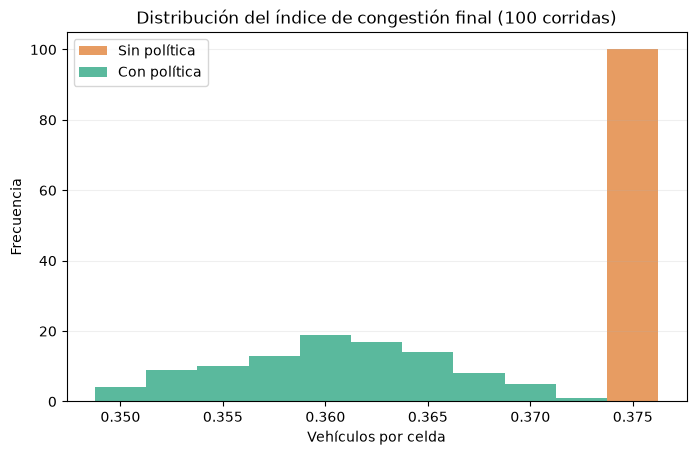

Valores almacenados: 100 y 100


In [7]:
M = 100
SIMULATION_SEEDS = np.arange(10_000, 10_000 + M)

y_without_policy = np.array(
    [run_simulation(False, int(seed)) for seed in SIMULATION_SEEDS]
)
y_with_policy = np.array(
    [run_simulation(True, int(seed)) for seed in SIMULATION_SEEDS]
)

vehicle_counts = np.rint(
    np.concatenate([y_without_policy, y_with_policy]) * N_CELLS
).astype(int)
bin_edges = (np.arange(vehicle_counts.min(), vehicle_counts.max() + 2) - 0.5) / N_CELLS

fig, ax = plt.subplots(figsize=(8, 4.8))
ax.hist(
    y_without_policy,
    bins=bin_edges,
    alpha=0.62,
    color="#d95f02",
    label="Sin política",
)
ax.hist(
    y_with_policy,
    bins=bin_edges,
    alpha=0.72,
    color="#1b9e77",
    label="Con política",
)
ax.set(
    title="Distribución del índice de congestión final (100 corridas)",
    xlabel="Vehículos por celda",
    ylabel="Frecuencia",
)
ax.legend()
ax.grid(axis="y", alpha=0.2)
plt.show()

print("Valores almacenados:", len(y_without_policy), "y", len(y_with_policy))


In [8]:
def scenario_statistics(values, relative_error=0.05, z_value=1.96):
    mean = float(np.mean(values))
    std = float(np.std(values, ddof=1))
    cv = std / mean if mean != 0 else np.nan
    minimum_runs = max(1, math.ceil((z_value * cv / relative_error) ** 2))
    return mean, std, cv, minimum_runs


stats_without = scenario_statistics(y_without_policy)
stats_with = scenario_statistics(y_with_policy)

print("Escenario       Media       DE          CV          M* (error relativo < 5%)")
for name, stats in [
    ("Sin política", stats_without),
    ("Con política", stats_with),
]:
    mean, std, cv, minimum_runs = stats
    print(f"{name:<14} {mean:>8.5f}   {std:>8.5f}   {cv:>8.5f}   {minimum_runs:>5}")

print(
    "\nInterpretación: la media es la densidad vehicular esperada al final;\n "
    "la desviación y el CV miden la variación entre réplicas.\n "
    "El escenario sin política es constante porque los 150 viajeros usan automóvil."
)


Escenario       Media       DE          CV          M* (error relativo < 5%)
Sin política    0.37500    0.00000    0.00000       1
Con política    0.36045    0.00530    0.01470       1

Interpretación: la media es la densidad vehicular esperada al final;
 la desviación y el CV miden la variación entre réplicas.
 El escenario sin política es constante porque los 150 viajeros usan automóvil.


## Task 2.2 - Bootstrap e intervalo para el efecto

El bootstrap remuestrea con reemplazo los 100 resultados observados. En cada una de las 2,000 remuestras se calcula la media; su desviación estándar aproxima el error estándar y sus percentiles 2.5 y 97.5 forman el intervalo de confianza solicitado sin asumir normalidad de $Y$.


In [9]:
def bootstrap_mean(values, B=2_000, seed=2026):
    '''Bootstrap completo de la media para un escenario.'''
    values = np.asarray(values, dtype=float)
    rng = np.random.default_rng(seed)
    resamples = rng.choice(values, size=(B, len(values)), replace=True)
    bootstrap_means = resamples.mean(axis=1)
    return {
        "mean": float(bootstrap_means.mean()),
        "standard_error": float(bootstrap_means.std(ddof=1)),
        "ci_95": tuple(np.percentile(bootstrap_means, [2.5, 97.5])),
        "replicates": bootstrap_means,
    }


bootstrap_without = bootstrap_mean(y_without_policy, B=2_000, seed=41)
bootstrap_with = bootstrap_mean(y_with_policy, B=2_000, seed=42)

for name, result in [
    ("Sin política", bootstrap_without),
    ("Con política", bootstrap_with),
]:
    low, high = result["ci_95"]
    print(
        f"{name}: media bootstrap={result['mean']:.6f}, "
        f"EE bootstrap={result['standard_error']:.6f}, "
        f"IC 95%=[{low:.6f}, {high:.6f}]"
    )


Sin política: media bootstrap=0.375000, EE bootstrap=0.000000, IC 95%=[0.375000, 0.375000]
Con política: media bootstrap=0.360430, EE bootstrap=0.000528, IC 95%=[0.359400, 0.361475]


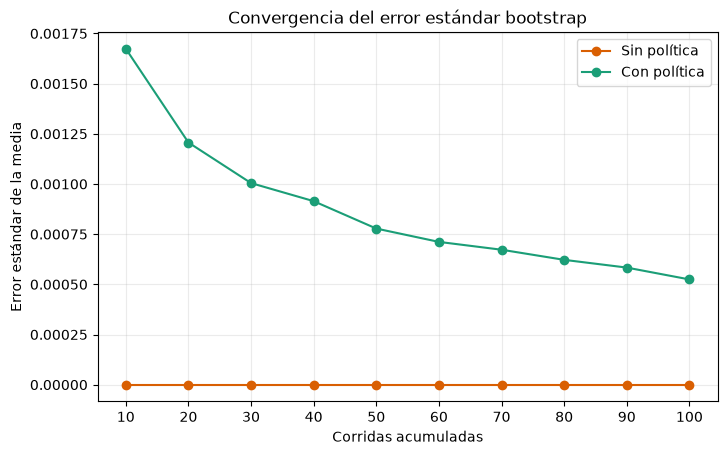

EE con política para M=70, 80, 90 y 100: [0.0006725 0.0006221 0.0005835 0.0005245]
Cambios absolutos en ese tramo: [5.04e-05 3.86e-05 5.90e-05]
Conclusión visual: la reducción del error es ya pequeña en el tramo final. Cien corridas son suficientes para el objetivo de 5% de este modelo, aunque no constituyen una regla universal para otros indicadores o parámetros.


In [10]:
accumulated_runs = np.arange(10, 101, 10)
se_without = []
se_with = []

for accumulated in accumulated_runs:
    se_without.append(
        bootstrap_mean(
            y_without_policy[:accumulated], B=2_000, seed=1_000 + accumulated
        )["standard_error"]
    )
    se_with.append(
        bootstrap_mean(
            y_with_policy[:accumulated], B=2_000, seed=2_000 + accumulated
        )["standard_error"]
    )

fig, ax = plt.subplots(figsize=(8, 4.8))
ax.plot(accumulated_runs, se_without, "o-", label="Sin política", color="#d95f02")
ax.plot(accumulated_runs, se_with, "o-", label="Con política", color="#1b9e77")
ax.set(
    title="Convergencia del error estándar bootstrap",
    xlabel="Corridas acumuladas",
    ylabel="Error estándar de la media",
    xticks=accumulated_runs,
)
ax.legend()
ax.grid(alpha=0.25)
plt.show()

last_changes = np.abs(np.diff(se_with[-4:]))
print("EE con política para M=70, 80, 90 y 100:", np.round(se_with[-4:], 7))
print("Cambios absolutos en ese tramo:", np.round(last_changes, 7))
print(
    "Conclusión visual: la reducción del error es ya pequeña en el tramo final. "
    "Cien corridas son suficientes para el objetivo de 5% de este modelo, "
    "aunque no constituyen una regla universal para otros indicadores o parámetros."
)


In [11]:
def bootstrap_difference(without_policy, with_policy, B=2_000, seed=2027):
    '''IC percentil para media(sin política) - media(con política).'''
    without_policy = np.asarray(without_policy, dtype=float)
    with_policy = np.asarray(with_policy, dtype=float)
    rng = np.random.default_rng(seed)

    without_resamples = rng.choice(
        without_policy, size=(B, len(without_policy)), replace=True
    )
    with_resamples = rng.choice(
        with_policy, size=(B, len(with_policy)), replace=True
    )
    differences = without_resamples.mean(axis=1) - with_resamples.mean(axis=1)

    point_estimate = float(without_policy.mean() - with_policy.mean())
    ci_95 = tuple(np.percentile(differences, [2.5, 97.5]))
    return point_estimate, ci_95, differences


delta_y, delta_ci, delta_replicates = bootstrap_difference(
    y_without_policy, y_with_policy, B=2_000, seed=43
)
delta_low, delta_high = delta_ci

print(f"Diferencia estimada: {delta_y:.6f} vehículos por celda")
print(f"IC bootstrap 95%: [{delta_low:.6f}, {delta_high:.6f}]")
print("¿Incluye cero?:", delta_low <= 0 <= delta_high)
print(
    "Interpretación:",
    "la política reduce significativamente la congestión en este modelo"
    if delta_low > 0
    else "la simulación no aporta evidencia concluyente de una reducción",
)


Diferencia estimada: 0.014550 vehículos por celda
IC bootstrap 95%: [0.013500, 0.015600]
¿Incluye cero?: False
Interpretación: la política reduce significativamente la congestión en este modelo


### Task 2.2(d) - Párrafo ejecutivo

La siguiente celda genera el texto directamente a partir de los resultados. No usa notación matemática.


In [14]:
executive_paragraph = (
    "Director de Planificación Urbana: en las simulaciones, implementar bicicletas \n"
    f"compartidas redujo la congestión media estimada en {delta_y:.4f} vehículos por \n"
    f"celda. El rango de resultados compatible con las remuestras va de {delta_low:.4f}\n "
    f"a {delta_high:.4f}; todo el rango representa una reducción, por lo que la evidencia\n "
    "del modelo es suficientemente consistente para recomendar un piloto de la política. \n"
    f"La estimación equivale aproximadamente a {delta_y * N_CELLS:.1f} automóviles menos \n"
    "dentro de la cuadrícula de cuatrocientas celdas. La recomendación debe tomarse con \n"
    "cautela: la decisión de transporte depende únicamente de una distancia de tres \n"
    "kilómetros y el indicador promedio no captura embotellamientos locales, costos, \n"
    "clima ni disponibilidad real de bicicletas. Conviene validar estos supuestos con \n"
    "datos locales antes de comprometer todo el presupuesto."
)

print(executive_paragraph)


Director de Planificación Urbana: en las simulaciones, implementar bicicletas 
compartidas redujo la congestión media estimada en 0.0146 vehículos por 
celda. El rango de resultados compatible con las remuestras va de 0.0135
 a 0.0156; todo el rango representa una reducción, por lo que la evidencia
 del modelo es suficientemente consistente para recomendar un piloto de la política. 
La estimación equivale aproximadamente a 5.8 automóviles menos 
dentro de la cuadrícula de cuatrocientas celdas. La recomendación debe tomarse con 
cautela: la decisión de transporte depende únicamente de una distancia de tres 
kilómetros y el indicador promedio no captura embotellamientos locales, costos, 
clima ni disponibilidad real de bicicletas. Conviene validar estos supuestos con 
datos locales antes de comprometer todo el presupuesto.
